# <font color= #83eac2 >**03 - Entrenamiento y Evaluación - NO SUPERVISADO** </font>

---

## <font color = #84c4da >**1. Importar bibliotecas y cargar datos** </font>
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pickle

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

pd.set_option('display.max_columns', None)


import sys
sys.path.append('../src')
from training import grafico_codo_inercia
from evaluation import entrenar_kmeans, scatterplot_kmeas


### **Cargar datos**

In [2]:
# Unir train y test procesados
train = pd.read_csv('../data/processed/train_processed.csv')
test  = pd.read_csv('../data/processed/test_processed.csv')

df_full = pd.concat([train, test], axis=0).reset_index(drop=True)

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")
print(f"Total: {df_full.shape}")
df_full.head(3)

Train: (4000, 10)
Test:  (1000, 10)
Total: (5000, 10)


,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Patient Satisfaction,categoria_espera
0,Monday,Summer,Evening,Critical,2,2,4,10,5,1
1,Wednesday,Winter,Evening,Low,4,42,80,123,1,4
2,Wednesday,Summer,Afternoon,Medium,4,16,21,53,2,3


### **Separar features y target**

In [3]:
# Separamos el target — no se usa para entrenar KMeans
# pero sí para evaluar al final
X = df_full.drop(columns='Patient Satisfaction')
y = df_full['Patient Satisfaction']

print(f"Features: {X.shape}")
print(f"Target:   {y.shape}")

Features: (5000, 9)
Target:   (5000,)


## <font color = #84c4da >**2. Preprocesamiento** </font>
---

**Para KMeans necesitamos que todas las variables sean numéricas y estén escaladas, KMeans usa distancias euclidianas y es sensible a la escala.**

In [4]:
# Mismas variables que en el supervisado
numericas = [
    'Nurse-to-Patient Ratio',
    'Time to Registration (min)',
    'Time to Triage (min)',
    'Time to Medical Professional (min)'
]

ordinales = [
    'Urgency Level',
    'Time of Day',
    'categoria_espera'
]

nominales = [
    'Season',
    'Day of Week'
]

# Preprocesador
urgency_order = [['Low', 'Medium', 'High', 'Critical']]
time_order    = [['Early Morning', 'Late Morning', 'Afternoon', 'Evening', 'Night']]
espera_order  = [[1, 2, 3, 4]]

preprocesador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numericas),
    ('ord', OrdinalEncoder(categories=urgency_order + time_order + espera_order), ordinales),
    ('nom', OneHotEncoder(drop='first', sparse_output=False), nominales)
])

# Transformar los datos
X_prep = preprocesador.fit_transform(X)
print(f"Shape tras preprocesamiento: {X_prep.shape}")

Shape tras preprocesamiento: (5000, 16)


## <font color = #84c4da >**3. Número óptimo de clusters - Método del Codo** </font>
---

### **Probamos diferentes valores de K y buscamos el punto donde la inercia deja de reducirse significativamente.**

In [5]:
inercias = []
silhouettes = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_prep)
    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_prep, kmeans.labels_))
    print(f"K={k} | Inercia: {kmeans.inertia_:.0f} | Silhouette: {silhouette_score(X_prep, kmeans.labels_):.4f}")

K=2 | Inercia: 25163 | Silhouette: 0.3464
K=3 | Inercia: 20481 | Silhouette: 0.2469
K=4 | Inercia: 17981 | Silhouette: 0.2475
K=5 | Inercia: 16228 | Silhouette: 0.2041
K=6 | Inercia: 14945 | Silhouette: 0.2063
K=7 | Inercia: 13924 | Silhouette: 0.1920
K=8 | Inercia: 13263 | Silhouette: 0.1791
K=9 | Inercia: 12798 | Silhouette: 0.1738
K=10 | Inercia: 12415 | Silhouette: 0.1579


### **Gráfico del codo**

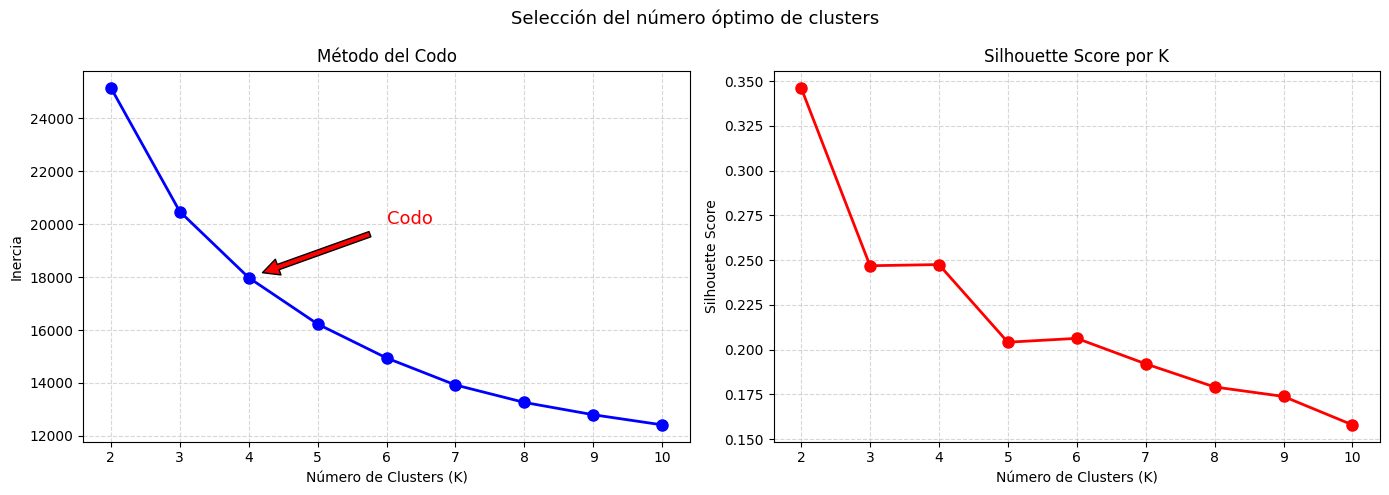

In [6]:
grafico_codo_inercia(K, inercias, silhouettes)

## <font color = #84c4da >**4. Entrenamiento KMeans con K=5** </font>
---

**Elegimos K=5 para comparar los clusters con los 5 niveles de satisfacción. Aunque el codo matemático está en K=4, K=5 tiene más sentido desde el punto de vista del negocio.**

In [7]:
# Entrenar
kmeans = entrenar_kmeans(X_prep, n_clusters=5)

# Añadir clusters al dataframe
df_full['cluster'] = kmeans.labels_

print(f"Clusters encontrados: {df_full['cluster'].nunique()}")
print(f"\nDistribución de clusters:")
print(df_full['cluster'].value_counts().sort_index())

KMeans entrenado con 5 clusters
Inercia: 16228
Clusters encontrados: 5

Distribución de clusters:
cluster
0    1236
1    1137
2    1115
3     893
4     619
Name: count, dtype: int64


## <font color = #84c4da >**5. Evaluación del modelo** </font>
---

### **5.1 Silhouette Score**

In [8]:
score = silhouette_score(X_prep, kmeans.labels_)
print(f"Silhouette Score K=5: {score:.4f}")

Silhouette Score K=5: 0.2041


In [9]:
# Comparar clusters con niveles de satisfacción reales
comparacion = pd.crosstab(
    df_full['cluster'], 
    df_full['Patient Satisfaction'],
    rownames=['Cluster'],
    colnames=['Patient Satisfaction']
)
print(comparacion)

Patient Satisfaction    1    2    3    4    5
Cluster                                      
0                       0    0   21  723  492
1                     870  252   15    0    0
2                       3  144  452  466   50
3                      46  209  385  240   13
4                     619    0    0    0    0


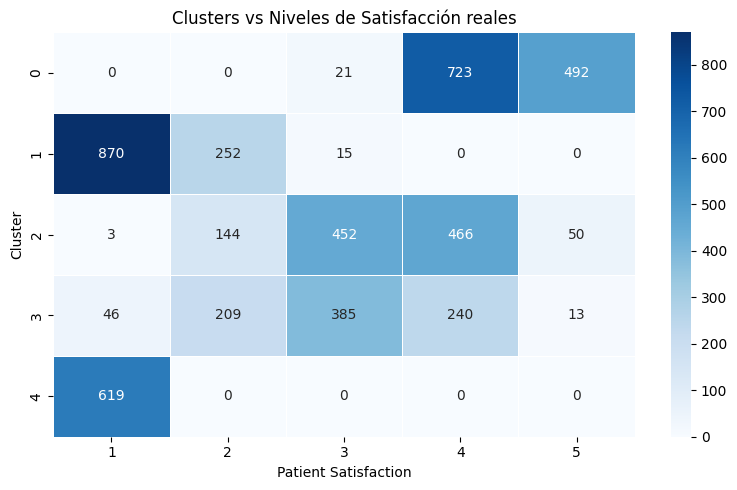

In [10]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    comparacion, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    linewidths=0.5
)
plt.title('Clusters vs Niveles de Satisfacción reales')
plt.tight_layout()
plt.show()

## <font color = #84c4da >**6. Análisis de Resultados** </font>
---

### **Interpretación de los clusters**

| Cluster | Satisfacción predominante | Interpretación |
|---|---|---|
| **Cluster 0** | 4 (723) y 5 (492) | Pacientes **muy satisfechos** |
| **Cluster 1** | 1 (870) y 2 (252) | Pacientes **muy insatisfechos** |
| **Cluster 2** | 3 (452) y 4 (466) | Pacientes **satisfacción media-alta** |
| **Cluster 3** | 2 (209) y 3 (385) | Pacientes **satisfacción media-baja** |
| **Cluster 4** | 1 (619) | Pacientes **insatisfechos** |

### **Conclusiones**

KMeans identificó **5 grupos naturales** en los datos que tienen una 
correspondencia clara con los niveles de satisfacción del target:

- Los clusters 0 y 2 agrupan pacientes satisfechos (niveles 4-5)
- Los clusters 1 y 4 agrupan pacientes insatisfechos (niveles 1-2)
- El cluster 3 agrupa pacientes con satisfacción intermedia (niveles 2-3)

KMeans **no separó perfectamente** las 5 clases — algunos clusters mezclan 
niveles adyacentes. Esto es consistente con lo observado en el modelo 
supervisado donde las clases intermedias (3 y 4) eran las más difíciles 
de separar.

El Silhouette Score de K=5 es bajo (~0.20) lo que indica que los clusters 
no están muy bien definidos — las fronteras entre niveles de satisfacción 
son difusas, lo cual tiene sentido en datos de experiencia del paciente.

## <font color = #84c4da >**7. Visualización con PCA** </font>
---
**Reducimos a 2 dimensiones con PCA para visualizar los clusters.**

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_prep)

print(f"Varianza explicada PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Varianza explicada PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum():.2%}")



Varianza explicada PC1: 59.08%
Varianza explicada PC2: 14.78%
Varianza total explicada: 73.86%


### **Varianza explicada**
- PC1 explica el **59.1%** de la varianza — es la componente más importante
- PC2 explica el **14.8%** de la varianza
- Entre las dos capturan el **73.9%** de la información total

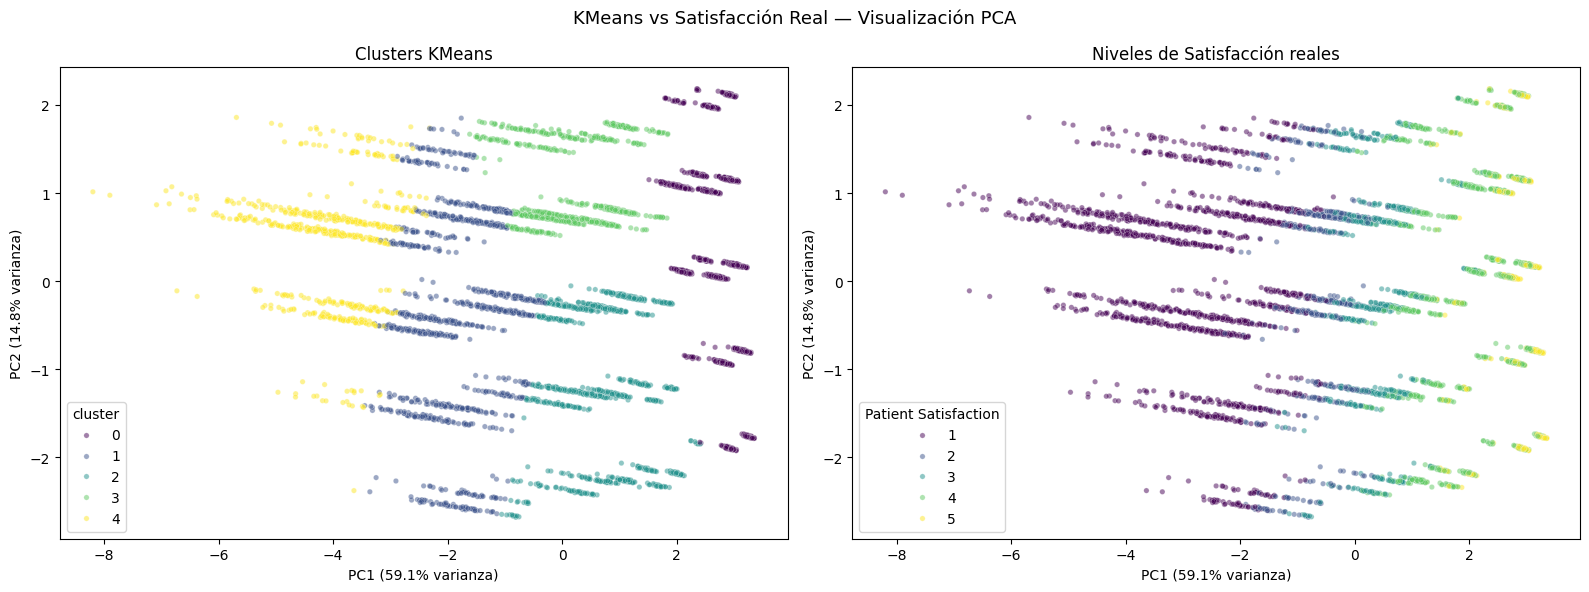

In [12]:
scatterplot_kmeas(X_pca,df_full,pca)

### **Análisis del gráfico**


**Gráfico izquierdo — Clusters KMeans:**
- Los clusters se distribuyen en **bandas diagonales** separadas
- KMeans separó los datos en grupos visualmente distinguibles
- Los colores están bastante bien separados a lo largo del eje PC1

**Gráfico derecho — Satisfacción real:**
- Los niveles reales siguen exactamente el **mismo patrón diagonal**
- Los niveles 1-2 (morado) se concentran en la derecha (PC1 alto)
- Los niveles 4-5 (amarillo/verde) se concentran en la izquierda (PC1 bajo)

### **Conclusión**

La estructura de los clusters de KMeans **coincide visualmente** con 
la distribución real de los niveles de satisfacción. PC1 captura 
principalmente la información de los **tiempos de espera** — la variable 
más importante del dataset según el heatmap de correlación.

Los patrones en bandas diagonales confirman que la satisfacción del 
paciente sigue un gradiente continuo relacionado principalmente con 
el tiempo de espera.

## <font color = #84c4da >**57. Guardar el modelo** </font>
---

In [13]:
with open('../models/trained_model_kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print("KMeans guardado")

KMeans guardado
